## I. Tiền Xử Lý Dữ Liệu Spam SMS
Pipeline gồm 8 bước: EDA → Xoá duplicate → Encode label → Làm sạch văn bản → Tokenize + Stopwords → Train/Test split → Vector hoá (TF-IDF) → Balance Dataset (SMOTE)

### Cài đặt thư viện

In [25]:
# Chạy cell này một lần để cài đặt
!pip install pandas scikit-learn nltk matplotlib seaborn imbalanced-learn


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\hary0\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


### Import thư viện

In [26]:
import pandas as pd # xử lý dữ liệu dạng bảng
import numpy as np # xử lý mảng, ma trận
import re # xử lý text (regex)
import pickle # lưu/truy xuất file nhị phân
import nltk # xử lý ngôn ngữ tự nhiên
from nltk.corpus import stopwords # loại bỏ stopwords (từ dừng)
from sklearn.model_selection import train_test_split # chia tập train/test
from sklearn.feature_extraction.text import TfidfVectorizer # trích xuất đặc trưng TF-IDF
from scipy.sparse import save_npz # lưu ma trận thưa dưới định dạng .npz
from imblearn.over_sampling import SMOTE # balance dataset
import matplotlib.pyplot as plt # visualize
import seaborn as sns # visualize
from collections import Counter # đếm từ

nltk.download('stopwords')

print('Import xong!')

Import xong!


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\hary0\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


### Bước 0: Load dữ liệu gốc

In [ ]:
# Load CSV
df = pd.read_csv('../data/spam.csv', encoding='latin-1')

# Rename cột
df = df.rename(columns={'Category': 'label', 'Message': 'message'})
df = df[['label', 'message']]

print(f'Shape: {df.shape}')
df.head(3)

Loaded ..\data\spam.csv bằng encoding utf-8
Shape: (4400, 2)
Columns: ['label', 'message']



,label,message
0,0,From rpm-list-admin@freshrpms.net Wed Oct 9 ...
1,1,From elizibeth-bradley@allexecs.org Mon Jun 2...
2,1,From fork-admin@xent.com Wed Aug 7 04:33:41 ...
3,0,From exmh-users-admin@redhat.com Thu Sep 19 1...
4,0,From jm@jmason.org Wed Sep 18 12:36:24 2002\n...


---
### Bước 1: EDA (Exploratory Data Analysis) — Khám phá dữ liệu
Khảo sát phân phối nhãn, độ dài tin nhắn, từ phổ biến và missing values trước khi xử lý.

Phân phối nhãn (giá trị gốc):
label
0    2501
1    1899
Name: count, dtype: int64



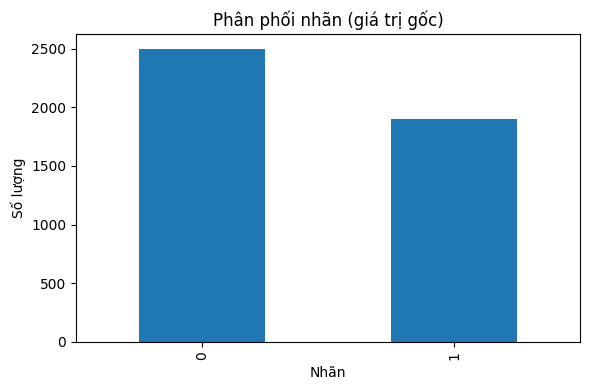

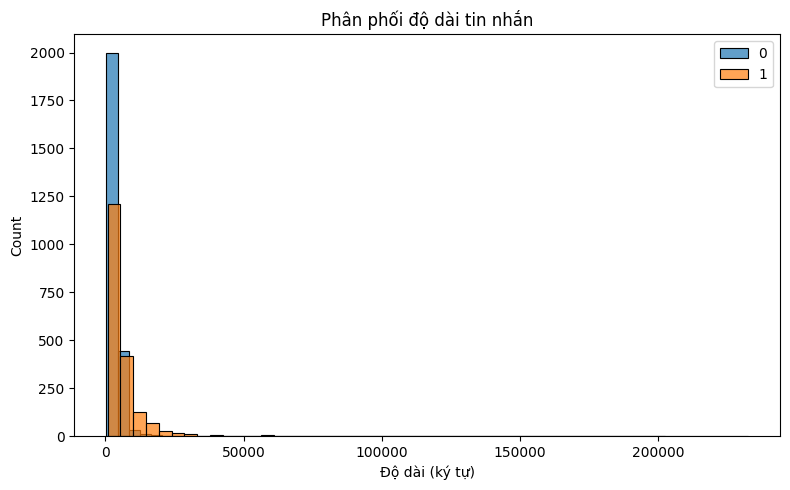

Top 20 từ phổ biến nhất (trước làm sạch):
  the: 43183
  to: 32740
  2002: 32638
  from: 30679
  for: 29450
  with: 27401
  by: 26599
  and: 24265
  of: 24000
  received:: 22271
  a: 20188
  >: 18868
  id: 16490
  in: 14621
  you: 14580
  is: 12947
  esmtp: 12561
  sep: 11851
  +0100: 11081
  this: 9906

Missing values:
label             0
message           0
message_length    0
dtype: int64

Số mẫu         : 4400
Độ dài trung bình: 4850.6 ký tự
Độ dài trung vị  : 3419.0 ký tự


In [28]:
# --- Phân phối nhãn (raw) ---
print('Phân phối nhãn (giá trị gốc):')
print(df['label'].value_counts(dropna=False))
print()

# --- Độ dài tin nhắn ---
df['message_length'] = df['message'].astype(str).str.len()

# --- Biểu đồ phân phối nhãn ---
plt.figure(figsize=(6, 4))
df['label'].value_counts().plot(kind='bar')
plt.title('Phân phối nhãn (giá trị gốc)')
plt.xlabel('Nhãn')
plt.ylabel('Số lượng')
plt.tight_layout()
plt.show()

# --- Biểu đồ độ dài tin nhắn (nhãn gốc dạng text) ---
plt.figure(figsize=(8, 5))
for lbl in df['label'].unique():
    sns.histplot(df[df['label'] == lbl]['message_length'], label=str(lbl), alpha=0.7, bins=50)
plt.title('Phân phối độ dài tin nhắn')
plt.xlabel('Độ dài (ký tự)')
plt.legend()
plt.tight_layout()
plt.show()

# --- Từ phổ biến (trước làm sạch) ---
all_words = ' '.join(df['message'].astype(str)).lower().split()
word_freq = Counter(all_words)
common_words = word_freq.most_common(20)
print('Top 20 từ phổ biến nhất (trước làm sạch):')
for word, freq in common_words:
    print(f'  {word}: {freq}')

# --- Missing values ---
print('\nMissing values:')
print(df.isnull().sum())

# --- Thống kê cơ bản ---
print(f'\nSố mẫu         : {len(df)}')
print(f'Độ dài trung bình: {df["message_length"].mean():.1f} ký tự')
print(f'Độ dài trung vị  : {df["message_length"].median():.1f} ký tự')

---
### Bước 2: Delete Duplicate
Loại bỏ các dòng trùng lặp để tránh **data leakage** khi chia tập train/test.

In [29]:
before = len(df)

df = df.drop_duplicates().reset_index(drop=True)

after = len(df)
print(f'Trước : {before} dòng')
print(f'Sau   : {after} dòng')
print(f'Đã xoá: {before - after} dòng trùng')

Trước : 4400 dòng
Sau   : 4400 dòng
Đã xoá: 0 dòng trùng


---
### Bước 3: Encode Label
Chuyển nhãn dạng text sang số: `ham → 0`, `spam → 1`.

In [30]:
if df['label'].dtype == object:
    df['label'] = df['label'].astype(str).str.strip().map({'ham': 0, 'spam': 1})

if df['label'].isnull().any():
    print('Cảnh báo: vẫn còn label NaN sau map. Các giá trị lạ:')
    print(df.loc[df['label'].isnull(), 'label'].head())

print('Phân phối nhãn sau encode:')
print(df['label'].value_counts(dropna=False))
print()
print(f'Null values: {df["label"].isnull().sum()}')
print(f'Tỷ lệ spam : {df["label"].mean():.2%}')

Phân phối nhãn sau encode:
label
0    2501
1    1899
Name: count, dtype: int64

Null values: 0
Tỷ lệ spam : 43.16%


---
### Bước 4: Text Cleaning
Chuẩn hoá text: lowercase, xoá URL, số, ký tự đặc biệt và khoảng trắng thừa.

In [31]:
def clean_text(text):
    text = str(text).lower()                          # lowercase
    text = re.sub(r'http\S+|www\S+', '', text)       # xoá URL
    text = re.sub(r'\d+', '', text)                   # xoá số
    text = re.sub(r'[^a-z\s]', '', text)              # xoá ký tự đặc biệt
    text = re.sub(r'\s+', ' ', text).strip()          # xoá khoảng trắng thừa
    return text

df['clean_msg'] = df['message'].apply(clean_text)

# Kiểm tra kết quả
print('Ví dụ trước/sau làm sạch:\n')
for i in [2, 5, 10]:
    print(f'  TRƯỚC: {df["message"].iloc[i][:90]}')
    print(f'  SAU  : {df["clean_msg"].iloc[i][:90]}')
    print()

Ví dụ trước/sau làm sạch:

  TRƯỚC: From fork-admin@xent.com  Wed Aug  7 04:33:41 2002
Return-Path: <fork-admin@xent.com>
Deli
  SAU  : from forkadminxentcom wed aug returnpath forkadminxentcom deliveredto yyyylocalhostnetnote

  TRƯỚC: From fork-admin@xent.com  Mon Aug 26 15:31:53 2002
Return-Path: <fork-admin@xent.com>
Deli
  SAU  : from forkadminxentcom mon aug returnpath forkadminxentcom deliveredto yyyylocalhostnetnote

  TRƯỚC: From garym@canada.com  Tue Sep 17 23:29:41 2002
Return-Path: <garym@canada.com>
Delivered-
  SAU  : from garymcanadacom tue sep returnpath garymcanadacom deliveredto yyyylocalhostspamassassi



---
### Bước 5: Tokenize + Loại Stopwords
Tách từ và loại bỏ các từ phổ biến không mang nhiều ý nghĩa (the, is, a, to...).

In [32]:
stop_words = set(stopwords.words('english'))

def tokenize_and_remove_stopwords(text):
    tokens = str(text).split()
    tokens = [t for t in tokens if t not in stop_words and len(t) > 1]
    return ' '.join(tokens)

df['processed'] = df['clean_msg'].apply(tokenize_and_remove_stopwords)

# Thống kê
avg_before = df['clean_msg'].str.split().apply(len).mean()
avg_after  = df['processed'].str.split().apply(len).mean()
print(f'Độ dài TB trước: {avg_before:.1f} từ/tin nhắn')
print(f'Độ dài TB sau  : {avg_after:.1f} từ/tin nhắn')
print()

# Xem ví dụ
print('Ví dụ trước/sau tokenize:\n')
for i in [0, 2, 10]:
    print(f'  TRƯỚC: {df["clean_msg"].iloc[i][:90]}')
    print(f'  SAU  : {df["processed"].iloc[i][:90]}')
    print()

Độ dài TB trước: 419.1 từ/tin nhắn
Độ dài TB sau  : 290.6 từ/tin nhắn

Ví dụ trước/sau tokenize:

  TRƯỚC: from rpmlistadminfreshrpmsnet wed oct returnpath rpmzzzlistadminfreshrpmsnet deliveredto z
  SAU  : rpmlistadminfreshrpmsnet wed oct returnpath rpmzzzlistadminfreshrpmsnet deliveredto zzzzlo

  TRƯỚC: from forkadminxentcom wed aug returnpath forkadminxentcom deliveredto yyyylocalhostnetnote
  SAU  : forkadminxentcom wed aug returnpath forkadminxentcom deliveredto yyyylocalhostnetnoteincco

  TRƯỚC: from garymcanadacom tue sep returnpath garymcanadacom deliveredto yyyylocalhostspamassassi
  SAU  : garymcanadacom tue sep returnpath garymcanadacom deliveredto yyyylocalhostspamassassintain



---
### Bước 6: Train / Test Split
Chia 80/20 với `stratify=label` để giữ nguyên tỉ lệ lớp ham/spam trong cả hai tập.

In [33]:
X_train, X_test, y_train, y_test = train_test_split(
    df['processed'],
    df['label'],
    test_size=0.2,
    stratify=df['label'],
    random_state=42
)

print(f'Train set : {len(X_train)} mẫu')
print(f'Test set  : {len(X_test)} mẫu')
print()
print('Tỉ lệ lớp trong train:')
print(y_train.value_counts(normalize=True).round(3))
print()
print('Tỉ lệ lớp trong test:')
print(y_test.value_counts(normalize=True).round(3))

Train set : 3520 mẫu
Test set  : 880 mẫu

Tỉ lệ lớp trong train:
label
0    0.568
1    0.432
Name: proportion, dtype: float64

Tỉ lệ lớp trong test:
label
0    0.568
1    0.432
Name: proportion, dtype: float64


---
### Bước 7: Vector Hoá (TF-IDF)
Chuyển văn bản thành vector số.

> **Quan trọng:** Chỉ `fit_transform` trên tập **train**, tập **test** chỉ dùng `transform` — tránh data leakage.

In [34]:
vectorizer = TfidfVectorizer(max_features=5000)

X_train_vec = vectorizer.fit_transform(X_train)   # fit + transform trên train
X_test_vec  = vectorizer.transform(X_test)        # chỉ transform trên test

print(f'Shape X_train_vec : {X_train_vec.shape}')
print(f'Shape X_test_vec  : {X_test_vec.shape}')

Shape X_train_vec : (3520, 5000)
Shape X_test_vec  : (880, 5000)


---
### Bước 8: Balance Dataset (SMOTE)
Dataset hiện tại imbalance (ham ~87%, spam ~13%). Dùng SMOTE để oversample lớp thiểu số (spam).

> **Quan trọng:** Chỉ áp dụng SMOTE trên **train set** để tránh data leakage.

In [35]:
# Áp dụng SMOTE chỉ trên train set để tránh data leakage
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_vec, y_train)

print(f'Trước balance: X_train {X_train_vec.shape}, y_train ham: {int((y_train==0).sum())}, spam: {int((y_train==1).sum())}')
print(f'Sau balance: X_train {X_train_balanced.shape}, y_train ham: {int((y_train_balanced==0).sum())}, spam: {int((y_train_balanced==1).sum())}')

# Cập nhật X_train_vec và y_train
X_train_vec = X_train_balanced
y_train = y_train_balanced
print(f'Số features (từ)  : {len(vectorizer.vocabulary_)}')

# Top 20 từ theo TF-IDF trung bình
feature_names = vectorizer.get_feature_names_out()
mean_tfidf    = np.asarray(X_train_vec.mean(axis=0)).flatten()
top20_idx     = mean_tfidf.argsort()[-20:][::-1]
print()
print('Top 20 từ có TF-IDF cao nhất:')
print([feature_names[i] for i in top20_idx])

Trước balance: X_train (3520, 5000), y_train ham: 2001, spam: 1519
Sau balance: X_train (4002, 5000), y_train ham: 2001, spam: 2001
Số features (từ)  : 5000

Top 20 từ có TF-IDF cao nhất:
['sep', 'received', 'oct', 'aug', 'id', 'thu', 'localhost', 'esmtp', 'tue', 'mon', 'wed', 'jul', 'td', 'tr', 'fri', 'jmlocalhost', 'jalapeno', 'ist', 'forkadminxentcom', 'postfix']


---
### Lưu kết quả

In [ ]:
import os
os.makedirs('../data', exist_ok=True)

# Lưu dataframe đã xử lý
df.to_csv('../data/spam_processed.csv', index=False)

# Lưu train/test set dạng CSV (trước SMOTE để giữ nhãn gốc)
train_df = pd.DataFrame({'text': X_train, 'label': y_test.reindex(X_train.index) if False else y_train_balanced[:len(X_train)]})
test_df  = pd.DataFrame({'text': X_test,  'label': y_test})
train_df.to_csv('../data/train.csv', index=False)
test_df.to_csv('../data/test.csv',   index=False)

# Lưu TF-IDF matrix
save_npz('../data/X_train.npz', X_train_vec)
save_npz('../data/X_test.npz',  X_test_vec)
np.save('../data/y_train.npy', y_train.values if hasattr(y_train, 'values') else y_train)
np.save('../data/y_test.npy',  y_test.values)

# Lưu vectorizer để dùng lại khi predict
with open('../data/tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(vectorizer, f)

print('✅ Đã lưu dữ liệu đã xử lý và balance vào ../data/')
print('   ../data/spam_processed.csv   — toàn bộ dataframe đã xử lý')
print('   ../data/train.csv / ../data/test.csv — tập train và test')
print('   ../data/X_train.npz / ../data/X_test.npz — ma trận TF-IDF')
print('   ../data/y_train.npy / ../data/y_test.npy — nhãn')
print('   ../data/tfidf_vectorizer.pkl — vectorizer (dùng khi predict)')

✅ Đã lưu dữ liệu đã xử lý và balance vào ../data/
   ../data/spam_processed.csv   — toàn bộ dataframe đã xử lý
   ../data/train.csv / ../data/test.csv — tập train và test
   ../data/X_train.npz / ../data/X_test.npz — ma trận TF-IDF
   ../data/y_train.npy / ../data/y_test.npy — nhãn
   ../data/tfidf_vectorizer.pkl — vectorizer (dùng khi predict)


: 